# Sign-Language Video Preprocessing

This notebook implements `plan.md` step by step.

The pipeline keeps the raw videos unchanged and writes a new processed dataset where each video is signer-centered, square-cropped, resized, and has a black background. The square crop is designed to preserve the face and both hands across the whole sign.

## 0. Environment Check

Run this notebook from the `video-mamba-suite` conda environment. This notebook does not install, uninstall, upgrade, downgrade, or print package-changing commands. If something is missing or version-mismatched, it reports the issue and stops.


In [6]:
import os
import sys
import importlib.util
from pathlib import Path

print('Python executable:', sys.executable)
print('CONDA_DEFAULT_ENV:', os.environ.get('CONDA_DEFAULT_ENV'))

if 'video-mamba-suite' not in sys.executable and os.environ.get('CONDA_DEFAULT_ENV') != 'video-mamba-suite':
    print('WARNING: This notebook should be run with the video-mamba-suite conda environment/kernel.')
    print('In terminal: conda activate video-mamba-suite')
    print('Then install/register the kernel if needed: python -m ipykernel install --user --name video-mamba-suite --display-name video-mamba-suite')

# Read-only dependency check. Do not install or change packages from this notebook.
# The training environment was validated with NumPy 1.x; NumPy 2.x can break compiled Torch/decord/mamba modules.
expected_versions = {
    'numpy': '1.26.4',
    'cv2': '4.11.0',
}
required_modules = [
    'cv2',
    'numpy',
    'pandas',
    'tqdm',
    'matplotlib',
    'ultralytics',
    'mediapipe',
]
problems = []
for module in required_modules:
    if importlib.util.find_spec(module) is None:
        problems.append(f'missing module: {module}')

try:
    import numpy as _np
    if _np.__version__ != expected_versions['numpy']:
        problems.append(f'numpy version is {_np.__version__}, expected {expected_versions["numpy"]}')
except Exception as exc:
    problems.append(f'could not import numpy: {exc}')

try:
    import cv2 as _cv2
    if _cv2.__version__ != expected_versions['cv2']:
        problems.append(f'cv2 version is {_cv2.__version__}, expected {expected_versions["cv2"]}')
except Exception as exc:
    problems.append(f'could not import cv2: {exc}')

if problems:
    print('Environment check failed:')
    for problem in problems:
        print('-', problem)
    print('\nNo packages were installed or changed by this notebook.')
    print('Ask before changing package versions in the video-mamba-suite environment.')
    raise RuntimeError('Preprocessing dependencies are missing or version-mismatched. No pip command was run.')

print('Environment check passed. No pip packages were changed.')

Python executable: /home/swagnik/miniconda3/envs/video-mamba-suite/bin/python
CONDA_DEFAULT_ENV: video-mamba-suite
Environment check passed. No pip packages were changed.


## 1. Configuration

Choose the raw dataset directory and output directory. The default follows `plan.md` and processes the Animals subset. Change `RAW_VIDEO_DIR` to another sign-language folder if needed, for example `Data/Clothes`, `Data/Colours`, or a full `Data/SignLanguage` directory.

In [7]:
from dataclasses import dataclass
from pathlib import Path

@dataclass
class PreprocessConfig:
    tcsr_root: Path = Path('/home/swagnik/swagnik/TCSR')
    raw_video_dir: Path = Path('/home/swagnik/swagnik/TCSR/Data/Animals')
    output_video_dir: Path = Path('/home/swagnik/swagnik/TCSR/Data/Animals_processed')
    report_dir: Path = Path('/home/swagnik/swagnik/TCSR/preprocess_reports')
    yolo_weights_dir: Path = Path('/home/swagnik/swagnik/TCSR/preprocess_reports/yolo_weights')

    output_resolution: int = 224
    detection_stride: int = 5
    confidence_threshold: float = 0.35
    padding_scale: float = 1.4
    minimum_valid_detections: int = 3

    use_segmentation: bool = True
    use_mediapipe_keypoints: bool = True
    yolo_seg_model: str = 'yolov8n-seg.pt'
    yolo_det_model: str = 'yolov8n.pt'

    preview_videos_per_class: int = 5
    preview_frames_per_video: int = 8
    video_exts: tuple = ('.mp4', '.avi', '.mov', '.mkv', '.webm', '.m4v')

CFG = PreprocessConfig()
CFG.output_video_dir.mkdir(parents=True, exist_ok=True)
CFG.report_dir.mkdir(parents=True, exist_ok=True)
(CFG.report_dir / 'sample_previews').mkdir(parents=True, exist_ok=True)
CFG.yolo_weights_dir.mkdir(parents=True, exist_ok=True)

print('Raw videos:', CFG.raw_video_dir)
print('Processed output:', CFG.output_video_dir)
print('Reports:', CFG.report_dir)

Raw videos: /home/swagnik/swagnik/TCSR/Data/Animals
Processed output: /home/swagnik/swagnik/TCSR/Data/Animals_processed
Reports: /home/swagnik/swagnik/TCSR/preprocess_reports


## 2. Discover Videos

The output preserves the same relative class-folder layout as the raw input.

In [8]:
import pandas as pd

VIDEO_EXTS = tuple(ext.lower() for ext in CFG.video_exts)

video_paths = sorted(
    p for p in CFG.raw_video_dir.rglob('*')
    if p.is_file() and p.suffix.lower() in VIDEO_EXTS
)

rows = []
for p in video_paths:
    rel = p.relative_to(CFG.raw_video_dir)
    class_name = rel.parent.as_posix()
    out_path = CFG.output_video_dir / rel
    rows.append({'input_path': p, 'relative_path': rel, 'class_name': class_name, 'output_path': out_path})

videos_df = pd.DataFrame(rows)
print('Videos found:', len(videos_df))
if len(videos_df):
    display(videos_df.groupby('class_name').size().rename('count').reset_index())
    display(videos_df.head())
else:
    raise FileNotFoundError(f'No videos found under {CFG.raw_video_dir}')

Videos found: 166


,class_name,count
0,1. Dog,20
1,2. Cat,20
2,3. Fish,20
3,4. Bird,20
4,4. Bird/Extra,5
5,5. Cow,21
6,6. Mouse,20
7,7. Horse,20
8,8. Animal,20


,input_path,relative_path,class_name,output_path
0,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,1. Dog/MVI_2978.MOV,1. Dog,/home/swagnik/swagnik/TCSR/Data/Animals_proces...
1,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,1. Dog/MVI_2979.MOV,1. Dog,/home/swagnik/swagnik/TCSR/Data/Animals_proces...
2,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,1. Dog/MVI_2980.MOV,1. Dog,/home/swagnik/swagnik/TCSR/Data/Animals_proces...
3,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,1. Dog/MVI_3002.MOV,1. Dog,/home/swagnik/swagnik/TCSR/Data/Animals_proces...
4,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,1. Dog/MVI_3003.MOV,1. Dog,/home/swagnik/swagnik/TCSR/Data/Animals_proces...


## 3. Load Detection, Segmentation, and Keypoint Models

YOLO finds the signer and can also provide a person segmentation mask. MediaPipe Holistic is used only to expand/check the crop using face and hand landmarks when they are visible.

In [9]:
import cv2
import numpy as np
from tqdm.auto import tqdm

from ultralytics import YOLO

try:
    import torch
    DEVICE = 0 if torch.cuda.is_available() else 'cpu'
except Exception:
    DEVICE = 'cpu'

print('YOLO device:', DEVICE)
seg_weights = CFG.yolo_weights_dir / CFG.yolo_seg_model
det_weights = CFG.yolo_weights_dir / CFG.yolo_det_model
print('YOLO weights directory:', CFG.yolo_weights_dir)

# If the weights are missing, Ultralytics may download only the .pt files into CFG.yolo_weights_dir.
# This does not install packages and does not touch the Video Mamba training outputs.
seg_model = YOLO(seg_weights) if CFG.use_segmentation else None
det_model = seg_model if seg_model is not None else YOLO(det_weights)

mp_holistic = None
if CFG.use_mediapipe_keypoints:
    try:
        import mediapipe as mp
        if hasattr(mp, 'solutions') and hasattr(mp.solutions, 'holistic'):
            mp_holistic = mp.solutions.holistic.Holistic(
                static_image_mode=False,
                model_complexity=1,
                refine_face_landmarks=True,
                min_detection_confidence=0.35,
                min_tracking_confidence=0.35,
            )
            print('MediaPipe Holistic enabled for face/hand crop preservation.')
        else:
            print('MediaPipe is installed, but mp.solutions.holistic is unavailable in this version.')
            print('Continuing with YOLO person boxes and padding only.')
    except Exception as exc:
        print('MediaPipe keypoints unavailable:', exc)
        print('Continuing with YOLO person boxes and padding only.')
else:
    print('MediaPipe keypoints disabled.')

YOLO device: 0
YOLO weights directory: /home/swagnik/swagnik/TCSR/preprocess_reports/yolo_weights
MediaPipe is installed, but mp.solutions.holistic is unavailable in this version.
Continuing with YOLO person boxes and padding only.


## 4. Utility Functions

These functions implement the core plan: read frames, detect signer boxes, include face/hand keypoints, build a stable square crop, black out the background, and resize to the final Video Mamba resolution.

In [10]:
from typing import Optional, Dict, List, Tuple

PERSON_CLASS_ID = 0

def read_video_metadata(video_path: Path) -> Dict:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f'Could not open video: {video_path}')
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return {'fps': fps, 'width': width, 'height': height, 'frame_count': frame_count}


def iter_sampled_frames(video_path: Path, stride: int):
    cap = cv2.VideoCapture(str(video_path))
    idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx % stride == 0:
            yield idx, frame
        idx += 1
    cap.release()


def largest_person_box(result, width: int, height: int, conf_thres: float) -> Optional[np.ndarray]:
    if result.boxes is None or len(result.boxes) == 0:
        return None
    boxes = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy().astype(int)

    candidates = []
    for box, conf, cls in zip(boxes, confs, classes):
        if cls != PERSON_CLASS_ID or conf < conf_thres:
            continue
        x1, y1, x2, y2 = box
        area = max(0, x2 - x1) * max(0, y2 - y1)
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        center_dist = ((cx - width / 2) ** 2 + (cy - height / 2) ** 2) ** 0.5
        candidates.append((area, -center_dist, conf, box))

    if not candidates:
        return None
    candidates.sort(reverse=True, key=lambda item: (item[0], item[1], item[2]))
    return candidates[0][3].astype(float)


def mediapipe_face_hand_points(frame_bgr: np.ndarray) -> np.ndarray:
    if mp_holistic is None:
        return np.zeros((0, 2), dtype=float)

    h, w = frame_bgr.shape[:2]
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    result = mp_holistic.process(rgb)
    points = []

    for landmarks in [result.face_landmarks, result.left_hand_landmarks, result.right_hand_landmarks]:
        if landmarks is None:
            continue
        for lm in landmarks.landmark:
            x = lm.x * w
            y = lm.y * h
            if -0.1 * w <= x <= 1.1 * w and -0.1 * h <= y <= 1.1 * h:
                points.append((x, y))

    return np.array(points, dtype=float) if points else np.zeros((0, 2), dtype=float)


def detect_video_motion_box(video_path: Path, cfg: PreprocessConfig) -> Tuple[Optional[np.ndarray], Dict]:
    meta = read_video_metadata(video_path)
    boxes = []
    keypoints = []
    sampled = 0

    for _, frame in iter_sampled_frames(video_path, cfg.detection_stride):
        sampled += 1
        h, w = frame.shape[:2]
        results = det_model.predict(frame, conf=cfg.confidence_threshold, classes=[PERSON_CLASS_ID], device=DEVICE, verbose=False)
        box = largest_person_box(results[0], w, h, cfg.confidence_threshold) if results else None
        if box is not None:
            boxes.append(box)
        pts = mediapipe_face_hand_points(frame)
        if len(pts):
            keypoints.append(pts)

    info = {
        **meta,
        'sampled_frames': sampled,
        'valid_person_detections': len(boxes),
        'keypoint_frames': len(keypoints),
        'used_full_frame_fallback': False,
    }

    if len(boxes) < cfg.minimum_valid_detections:
        info['used_full_frame_fallback'] = True
        return None, info

    box_array = np.vstack(boxes)
    xs = [box_array[:, 0].min(), box_array[:, 2].max()]
    ys = [box_array[:, 1].min(), box_array[:, 3].max()]

    if keypoints:
        pts = np.vstack(keypoints)
        xs.extend([pts[:, 0].min(), pts[:, 0].max()])
        ys.extend([pts[:, 1].min(), pts[:, 1].max()])

    motion_box = np.array([min(xs), min(ys), max(xs), max(ys)], dtype=float)
    return motion_box, info


def square_crop_from_box(box: Optional[np.ndarray], width: int, height: int, padding_scale: float) -> Tuple[int, int, int, int]:
    if box is None:
        side = max(width, height)
        cx, cy = width / 2, height / 2
    else:
        x1, y1, x2, y2 = box
        bw = max(1.0, x2 - x1)
        bh = max(1.0, y2 - y1)
        side = max(bw, bh) * padding_scale
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2

    side = int(np.ceil(side))
    x1 = int(round(cx - side / 2))
    y1 = int(round(cy - side / 2))
    x2 = x1 + side
    y2 = y1 + side
    return x1, y1, x2, y2


def crop_with_black_padding(frame: np.ndarray, crop: Tuple[int, int, int, int]) -> np.ndarray:
    x1, y1, x2, y2 = crop
    side = x2 - x1
    out = np.zeros((side, side, 3), dtype=frame.dtype)
    h, w = frame.shape[:2]

    src_x1 = max(0, x1)
    src_y1 = max(0, y1)
    src_x2 = min(w, x2)
    src_y2 = min(h, y2)

    dst_x1 = src_x1 - x1
    dst_y1 = src_y1 - y1
    dst_x2 = dst_x1 + max(0, src_x2 - src_x1)
    dst_y2 = dst_y1 + max(0, src_y2 - src_y1)

    if src_x2 > src_x1 and src_y2 > src_y1:
        out[dst_y1:dst_y2, dst_x1:dst_x2] = frame[src_y1:src_y2, src_x1:src_x2]
    return out


def person_mask_for_frame(frame_bgr: np.ndarray) -> Optional[np.ndarray]:
    if seg_model is None:
        return None
    results = seg_model.predict(frame_bgr, conf=CFG.confidence_threshold, classes=[PERSON_CLASS_ID], device=DEVICE, verbose=False)
    if not results or results[0].masks is None or results[0].boxes is None or len(results[0].boxes) == 0:
        return None

    result = results[0]
    boxes = result.boxes.xyxy.detach().cpu().numpy()
    confs = result.boxes.conf.detach().cpu().numpy()
    classes = result.boxes.cls.detach().cpu().numpy().astype(int)
    masks = result.masks.data.detach().cpu().numpy()

    best_idx = None
    best_score = -1
    h, w = frame_bgr.shape[:2]
    for i, (box, conf, cls) in enumerate(zip(boxes, confs, classes)):
        if cls != PERSON_CLASS_ID or conf < CFG.confidence_threshold:
            continue
        x1, y1, x2, y2 = box
        area = max(0, x2 - x1) * max(0, y2 - y1)
        score = area * conf
        if score > best_score:
            best_score = score
            best_idx = i

    if best_idx is None:
        return None

    mask = masks[best_idx]
    mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_LINEAR)
    mask = (mask > 0.5).astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    mask = cv2.dilate(mask, np.ones((3, 3), np.uint8), iterations=1)
    return mask


def apply_black_background(frame_bgr: np.ndarray) -> np.ndarray:
    mask = person_mask_for_frame(frame_bgr)
    if mask is None:
        return frame_bgr
    return frame_bgr * mask[:, :, None]

## 5. Process One Video

This cell performs the full pipeline for a single video:

1. detect signer across sampled frames
2. include face and hand keypoints when available
3. make a stable square crop for the whole video
4. remove background to black
5. crop/pad/resize
6. save with original FPS

In [11]:
def process_video(input_path: Path, output_path: Path, cfg: PreprocessConfig, overwrite: bool = False) -> Dict:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists() and not overwrite:
        meta = read_video_metadata(input_path)
        return {'input_path': str(input_path), 'output_path': str(output_path), 'status': 'skipped_exists', **meta}

    motion_box, info = detect_video_motion_box(input_path, cfg)
    crop = square_crop_from_box(motion_box, info['width'], info['height'], cfg.padding_scale)

    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        return {'input_path': str(input_path), 'output_path': str(output_path), 'status': 'open_failed', **info}

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(str(output_path), fourcc, info['fps'], (cfg.output_resolution, cfg.output_resolution))
    if not writer.isOpened():
        cap.release()
        return {'input_path': str(input_path), 'output_path': str(output_path), 'status': 'writer_failed', **info}

    written = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        bg_removed = apply_black_background(frame) if cfg.use_segmentation else frame
        cropped = crop_with_black_padding(bg_removed, crop)
        resized = cv2.resize(cropped, (cfg.output_resolution, cfg.output_resolution), interpolation=cv2.INTER_AREA)
        writer.write(resized)
        written += 1

    cap.release()
    writer.release()

    return {
        'input_path': str(input_path),
        'output_path': str(output_path),
        'status': 'ok',
        'crop_x1': crop[0],
        'crop_y1': crop[1],
        'crop_x2': crop[2],
        'crop_y2': crop[3],
        'output_frames': written,
        **info,
    }

## 6. Quick Test on One Video

Run this before processing the full dataset. Inspect the preview and make sure the face and both hands are inside the square crop.

In [12]:
TEST_INDEX = 0
OVERWRITE_TEST = True

test_row = videos_df.iloc[TEST_INDEX]
test_output = CFG.output_video_dir / test_row['relative_path']
result = process_video(test_row['input_path'], test_output, CFG, overwrite=OVERWRITE_TEST)
result

/home/swagnik/miniconda3/envs/video-mamba-suite/lib/python3.9/site-packages/torch/nn/modules/conv.py:456: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


{'input_path': '/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog/MVI_2978.MOV',
 'output_path': '/home/swagnik/swagnik/TCSR/Data/Animals_processed/1. Dog/MVI_2978.MOV',
 'status': 'ok',
 'crop_x1': 389,
 'crop_y1': -61,
 'crop_x2': 1714,
 'crop_y2': 1264,
 'output_frames': 117,
 'fps': 25.0,
 'width': 1920,
 'height': 1080,
 'frame_count': 117,
 'sampled_frames': 24,
 'valid_person_detections': 24,
 'keypoint_frames': 0,
 'used_full_frame_fallback': False}

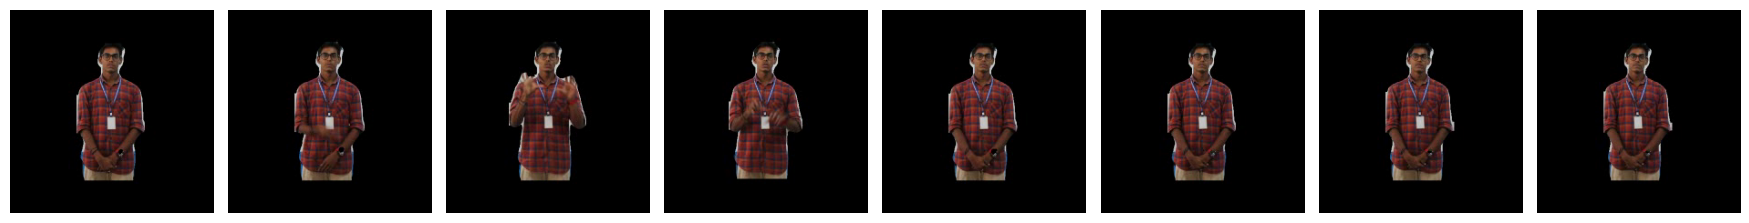

Preview video: /home/swagnik/swagnik/TCSR/Data/Animals_processed/1. Dog/MVI_2978.MOV


In [13]:
import matplotlib.pyplot as plt

def sample_video_frames(video_path: Path, n: int = 8) -> List[np.ndarray]:
    meta = read_video_metadata(video_path)
    total = max(1, meta['frame_count'])
    indices = np.linspace(0, total - 1, n).astype(int)
    wanted = set(indices.tolist())
    frames = []
    cap = cv2.VideoCapture(str(video_path))
    idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if idx in wanted:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        idx += 1
    cap.release()
    return frames

frames = sample_video_frames(test_output, CFG.preview_frames_per_video)
fig, axes = plt.subplots(1, len(frames), figsize=(2.2 * len(frames), 2.4))
if len(frames) == 1:
    axes = [axes]
for ax, frame in zip(axes, frames):
    ax.imshow(frame)
    ax.axis('off')
plt.tight_layout()
plt.show()
print('Preview video:', test_output)

## 7. Process the Full Dataset

This writes processed videos to `CFG.output_video_dir` and creates CSV/TXT reports. Set `OVERWRITE_ALL=True` only when you want to regenerate outputs.

In [14]:
OVERWRITE_ALL = False

results = []
for row in tqdm(videos_df.itertuples(index=False), total=len(videos_df), desc='Processing videos'):
    results.append(process_video(row.input_path, row.output_path, CFG, overwrite=OVERWRITE_ALL))

results_df = pd.DataFrame(results)
report_csv = CFG.report_dir / 'preprocess_results.csv'
results_df.to_csv(report_csv, index=False)
print('Saved report:', report_csv)
display(results_df['status'].value_counts().rename_axis('status').reset_index(name='count'))
display(results_df.head())

Processing videos: 100%|██████████| 166/166 [09:56<00:00,  3.60s/it]

Saved report: /home/swagnik/swagnik/TCSR/preprocess_reports/preprocess_results.csv


,status,count
0,ok,165
1,skipped_exists,1


,input_path,output_path,status,fps,width,height,frame_count,crop_x1,crop_y1,crop_x2,crop_y2,output_frames,sampled_frames,valid_person_detections,keypoint_frames,used_full_frame_fallback
0,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,/home/swagnik/swagnik/TCSR/Data/Animals_proces...,skipped_exists,25.0,1920,1080,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,/home/swagnik/swagnik/TCSR/Data/Animals_proces...,ok,25.0,1920,1080,76,390.0,-55.0,1707.0,1262.0,76.0,16.0,16.0,0.0,False
2,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,/home/swagnik/swagnik/TCSR/Data/Animals_proces...,ok,25.0,1920,1080,89,392.0,-57.0,1711.0,1262.0,89.0,18.0,18.0,0.0,False
3,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,/home/swagnik/swagnik/TCSR/Data/Animals_proces...,ok,25.0,1920,1080,87,366.0,61.0,1543.0,1238.0,87.0,18.0,18.0,0.0,False
4,/home/swagnik/swagnik/TCSR/Data/Animals/1. Dog...,/home/swagnik/swagnik/TCSR/Data/Animals_proces...,ok,25.0,1920,1080,92,360.0,63.0,1537.0,1240.0,92.0,19.0,19.0,0.0,False


## 8. Detection Failure Report

Videos with too few person detections are processed using a full-frame square fallback and logged for manual inspection.

In [ ]:
failure_file = CFG.report_dir / 'detection_failures.txt'
failure_df = results_df[results_df.get('used_full_frame_fallback', False) == True]
with open(failure_file, 'w') as f:
    for path in failure_df['input_path'].tolist():
        f.write(path + '\n')

print('Detection fallback videos:', len(failure_df))
print('Saved:', failure_file)
if len(failure_df):
    display(failure_df[['input_path', 'valid_person_detections', 'sampled_frames', 'keypoint_frames', 'status']].head(20))

## 9. Generate Class Preview Contact Sheets

Use these previews to confirm that the square crop preserves the face and both hands, and that the background is black.

In [ ]:
def make_contact_sheet(video_paths: List[Path], output_path: Path, frames_per_video: int):
    rows = []
    for path in video_paths:
        frames = sample_video_frames(path, frames_per_video)
        if not frames:
            continue
        rows.append(frames)

    if not rows:
        return None

    h, w = rows[0][0].shape[:2]
    sheet = np.zeros((h * len(rows), w * frames_per_video, 3), dtype=np.uint8)
    for r, frames in enumerate(rows):
        for c, frame in enumerate(frames[:frames_per_video]):
            sheet[r*h:(r+1)*h, c*w:(c+1)*w] = frame

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), cv2.cvtColor(sheet, cv2.COLOR_RGB2BGR))
    return output_path

preview_rows = []
for class_name, group in videos_df.groupby('class_name'):
    processed_paths = [CFG.output_video_dir / rel for rel in group['relative_path'].head(CFG.preview_videos_per_class)]
    safe_name = class_name.replace('/', '__').replace(' ', '_') or 'root'
    preview_path = CFG.report_dir / 'sample_previews' / f'{safe_name}.jpg'
    made = make_contact_sheet(processed_paths, preview_path, CFG.preview_frames_per_video)
    if made is not None:
        preview_rows.append({'class_name': class_name, 'preview_path': made})

preview_df = pd.DataFrame(preview_rows)
display(preview_df)
print('Preview directory:', CFG.report_dir / 'sample_previews')

## 10. Final Dataset Summary

Use `CFG.output_video_dir` as the raw video directory in your Video Mamba training notebook after inspection passes.

In [1]:
processed_paths = sorted(
    p for p in CFG.output_video_dir.rglob('*')
    if p.is_file() and p.suffix.lower() in VIDEO_EXTS
)
summary_rows = []
for p in processed_paths:
    rel = p.relative_to(CFG.output_video_dir)
    summary_rows.append({'class_name': rel.parent.as_posix(), 'path': p})
summary_df = pd.DataFrame(summary_rows)

print('Processed videos:', len(summary_df))
print('Processed dataset directory:', CFG.output_video_dir)
if len(summary_df):
    display(summary_df.groupby('class_name').size().rename('count').reset_index())

print('\nNext step: in the Video Mamba training notebook, set RAW_VIDEO_DIR to:')
print(CFG.output_video_dir)

NameError: name 'CFG' is not defined